In [1]:
#!/usr/bin/env python3
import os
import re
import sys
import collections
import argparse
import itertools 
import scipy
import matplotlib
import glob
from tqdm import tqdm

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42



import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from multiprocessing import Pool
from collections import defaultdict
from scipy import sparse
from scipy.sparse import csr_matrix
from scipy.cluster.hierarchy import dendrogram, linkage
import scipy.io as io

In [2]:
length_list = [0, 248956422, 491149951, 689445510, 879660065, 1061198324,
               1232004303, 1391350276, 1536488912, 1674883629, 1808681051,
               1943767673, 2077042982, 2191407310, 2298451028, 2400442217,
               2490780562, 2574038003, 2654411288, 2713028904, 2777473071,
               2824183054, 2875001522, 3031042417]

chr_order = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11',
             '12', '13', '14', '15', '16', '17', '18', '19', '20',
             '21', '22', 'X', 'Y']

v2_FILE = '/project/GCRB/Hon_lab/shared/former_members/s160875/03.analysis/Mosaic-seq/CROP-DE-analysis_10X-66K_no_downsampling-CPM.hg38/\
combine_10sgRNAs-volcano/generate_annotations/plot_annotation.txt'

annot_df_dup = pd.read_csv(v2_FILE,
        header = None,
        sep='\t',
        names = ['idx', 'gene_names', 'chromosome', 'pos', 'strand', 'color_idx', 'chr_idx'])

In [3]:
#Load annotation file 
annot_dict_file = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20240219_WTC11_TFPerturb_CM-full_all/pySpade/annotation_dict_hg38.txt'
annot_dict = {}
with open(annot_dict_file) as f:
    for line in f:
        region_id, annotation = line.strip().split("\t")
        annot_dict.update({region_id : annotation})

In [4]:
TF_region_df = pd.DataFrame.from_dict(annot_dict, columns=['TF'], orient='index')

In [5]:
TF_region_df.head(3)

,TF
chr11:5301689-5301949,OR51B4
chr19:51887666-51887940,ZNF577
chrX:72276872-72277245,RPS4X


### Slice repetitive elements and zinc finger protein

In [6]:
RE_annotation_df = pd.read_csv('/project/GCRB/Hon_lab/s159317/IGVF/scTE_mapping/CM.TF-Perturb-Seq/temp/rmsk.txt', sep='\t', 
                               names=['1', '2', '3', '4', '5', 'chr', 'start', 'end', 'pos', 'strand', 'name', 'cate', 'names', '6', '7', '8', '9'])

In [7]:
RE_annotation_df.head()

,1,2,3,4,5,chr,start,end,pos,strand,name,cate,names,6,7,8,9
0,585,463,13,6,17,chr1,10000,10468,-248945954,+,(TAACCC)n,Simple_repeat,Simple_repeat,1,471,0,1
1,585,3612,114,215,13,chr1,10468,11447,-248944975,-,TAR1,Satellite,telo,-399,1712,483,2
2,585,484,251,132,0,chr1,11504,11675,-248944747,-,L1MC5a,LINE,L1,-2382,395,199,3
3,585,239,294,19,10,chr1,11677,11780,-248944642,-,MER5B,DNA,hAT-Charlie,-74,104,1,4
4,585,318,230,37,0,chr1,15264,15355,-248941067,-,MIR3,SINE,MIR,-119,143,49,5


### Load DE table

In [8]:
GLBOAL_HITS = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/pySpade/unfiltered_global_df.csv'
FILE_DIR = '/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/pySpade/'

In [9]:
df_column_list = [
    'idx', 'gene_names', 'chromosome', 'pos', 'strand', 
    'color_idx', 'chr_idx', 
    'region', 'num_cell', 'bin',
    'log(pval)-hypergeom', 'fc', 'Significance_score', 'fc_by_rand_dist_cpm', 'pval-empirical', 'cpm_perturb', 'cpm_bg']

In [10]:
global_df = pd.read_csv(GLBOAL_HITS)[df_column_list]

In [11]:
global_df['TF_annotation'] = [annot_dict[i] for i in global_df['region']]

In [12]:
global_df_TE = global_df.loc[global_df["gene_names"].isin(RE_annotation_df["name"])]

### Load expression data

In [13]:
CUTOFF_EXP = 0.05
CUTOFF_FC = 0.2
CUTOFF_SIG = -14

In [14]:
#Load expressed genes 
gene_seq = np.load(FILE_DIR + 'Trans_genome_seq.npy', allow_pickle=True)
express_level = np.load(FILE_DIR + 'Perc_cell_expr.npy')
express_idx = np.where(express_level > CUTOFF_EXP)[0]

In [15]:
exp_percent_df = pd.DataFrame([gene_seq,express_level]).T
exp_percent_df.columns = ["Name","express_level"]

In [16]:
np.percentile(exp_percent_df.loc[
    exp_percent_df["Name"].isin(RE_annotation_df["name"])]["express_level"],10)

0.3118368628469968

### Check positive control interaction

In [17]:
te_zfp_df = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/20250218_TE_analysis_CM/TE_ZFP_table.csv",
                        index_col=0
                       )
te_names_col = [x.split("/")[2] for x in te_zfp_df.columns]
te_zfp_df.columns = te_names_col

In [19]:
te_zfp_df_melt = te_zfp_df.melt(ignore_index=False).reset_index().sort_values("value",ascending=False)
te_zfp_df_melt_match = te_zfp_df_melt[te_zfp_df_melt["index"].isin(global_df_TE["TF_annotation"]) &
                                      te_zfp_df_melt["variable"].isin(global_df_TE["gene_names"])
                                     ]

In [20]:
positive_interaction = te_zfp_df_melt_match.iloc[100:1100,[0,1]].values
negative_interaction = te_zfp_df_melt_match.iloc[-1000:,[0,1]].values

In [21]:
global_df_TE_pivot = global_df_TE.pivot_table(columns="gene_names",index="TF_annotation",values="Significance_score")
global_df_TE_pivot = global_df_TE_pivot.fillna(0)

In [22]:
global_df_TE_pivot.head()

gene_names,(CATTC)n,(GAATG)n,ACRO1,ALR/Alpha,Alu,AluJb,AluJo,AluJr,AluJr4,AluSc,...,X7B_LINE,X7C_LINE,X7D_LINE,X8_LINE,X9_LINE,Zaphod,Zaphod2,Zaphod3,hAT-16_Crp,hAT-N1_Mam
TF_annotation,,,,,,,,,,,,,,,,,,,,,
ADNP,0.0,0.0,0.0,-0.542585,-3.916157,-1.235873,-0.528620,-1.553495,-1.288338,-0.875671,...,-1.249611,0.000000,0.000000,0.000000,-1.895518,-1.188777,0.000000,-2.540926,0.000000,-1.414432
ADNP2,0.0,0.0,0.0,-1.566414,-0.931349,-1.591358,-0.278597,-0.358157,-1.048346,-1.039362,...,-1.686870,-1.172088,-2.865205,-1.257661,-1.366445,-1.138067,-1.830940,-3.527077,-0.942658,-0.951992
AEBP1,0.0,0.0,0.0,-1.786160,-0.177146,-3.476965,-3.911055,-1.482297,-1.445218,-2.756146,...,-2.389694,-5.614002,0.000000,0.000000,-1.454307,-1.110836,-2.967745,-1.311180,-1.276374,-2.366826
AEBP2,0.0,0.0,0.0,-1.917299,-1.388738,-3.467641,-1.929725,-2.805451,-2.397895,-2.952542,...,-0.889472,-2.189860,0.000000,0.000000,-1.087680,-1.052337,-3.315346,-0.832910,0.000000,-2.477727
AFF1,0.0,0.0,0.0,-0.816220,-0.450567,-4.597421,-6.187181,-4.158771,-5.279706,-5.916839,...,-1.713321,-0.792220,-0.909983,-0.668260,-1.571953,-1.750963,-1.712343,-1.210798,-1.990499,-0.993445


In [23]:
ChIP_pos_interaction = []
ChIP_neg_interaction = []
for gene_name,te_name in positive_interaction:
    ChIP_pos_interaction.append([global_df_TE_pivot.at[gene_name,te_name]])
    
for gene_name,te_name in negative_interaction:
    ChIP_neg_interaction.append([global_df_TE_pivot.at[gene_name,te_name]])

ChIP_pos_interaction  = np.concatenate(ChIP_pos_interaction)
ChIP_neg_interaction  = np.concatenate(ChIP_neg_interaction)
total_data = [ChIP_pos_interaction,ChIP_neg_interaction]

In [24]:
positive_interaction[np.where(ChIP_pos_interaction<-15)]

array([['ZNF561', 'LTR10C'],
       ['ZNF562', 'LTR10B2'],
       ['ZNF562', 'LTR10B'],
       ['ZNF189', 'LTR1A2']], dtype=object)

<Axes: ylabel='Count'>

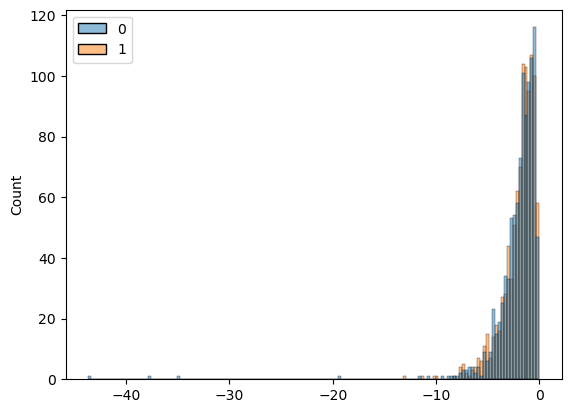

In [25]:
sns.histplot(total_data)

### Finding good cutoff for TE analysis

In [26]:
PC_gene_list = ["SETDB1","TRIM28","REST"]

In [27]:
tf_list = np.unique(global_df_TE["TF_annotation"])
OR_gene_list = ["OR10G4","OR10H2","OR10H5","OR10K1","OR10V1",
                "OR11H6","OR11L1","OR12D2","OR13C9","OR13G1",
                "OR1J4","OR1L8","OR1M1","OR1N2","OR2A1",
                "OR2A2","OR2AE1","OR2B2","OR2H1","OR2H2"]

In [28]:
CUTOFF_SIG_list = list(range(-15,-4))

In [29]:
sig_filter_df = pd.DataFrame(index=PC_gene_list + OR_gene_list,columns=CUTOFF_SIG_list)

for cut_off_tmp in CUTOFF_SIG_list:
    print("cutoff:",cut_off_tmp)
    sig_TE_dict = {}
    global_df_TE_select = global_df_TE[(global_df_TE['gene_names'].isin(gene_seq[express_idx])) &
                                       ((global_df_TE['fc_by_rand_dist_cpm'] > (1+CUTOFF_FC)) |
                                        (global_df_TE['fc_by_rand_dist_cpm'] < (1-CUTOFF_FC))) & 
                                       (global_df_TE['pval-empirical'] < 0.001) &
                                       (global_df_TE['log(pval)-hypergeom'] < -3) &
                                       (global_df_TE["Significance_score"]<cut_off_tmp)]
    
    for gene in PC_gene_list + OR_gene_list:
        global_df_TE_target = global_df_TE_select[(global_df_TE_select["TF_annotation"]==gene)]
        sig_TE_dict[gene] = global_df_TE_target.shape[0]
        sig_filter_df.loc[:,cut_off_tmp] = sig_TE_dict

cutoff: -15
cutoff: -14
cutoff: -13
cutoff: -12
cutoff: -11
cutoff: -10
cutoff: -9
cutoff: -8
cutoff: -7
cutoff: -6
cutoff: -5


In [30]:
sig_filter_df["control"] = np.isin(sig_filter_df.index,PC_gene_list)

In [31]:
sig_filter_df.head(8)

,-15,-14,-13,-12,-11,-10,-9,-8,-7,-6,-5,control
SETDB1,0,0,0,0,0,0,0,2,4,6,8,True
TRIM28,0,0,0,0,1,1,1,4,6,11,11,True
REST,0,0,0,0,0,0,2,3,6,7,7,True
OR10G4,0,0,0,0,0,0,0,1,3,3,3,False
OR10H2,0,0,0,0,0,0,1,1,1,2,2,False
OR10H5,0,0,0,0,0,0,0,0,1,1,1,False
OR10K1,0,0,0,0,0,0,0,1,1,2,2,False
OR10V1,0,0,0,0,0,0,0,0,2,2,2,False


In [32]:
sig_filter_df_melt = sig_filter_df.melt(id_vars=["control"],ignore_index=False)

In [33]:
sig_filter_df_melt.head()

,control,variable,value
SETDB1,True,-15,0
TRIM28,True,-15,0
REST,True,-15,0
OR10G4,False,-15,0
OR10H2,False,-15,0


/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 47.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 43.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 34.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 13.0% of the points cannot be placed; you may want to decrease the size of 

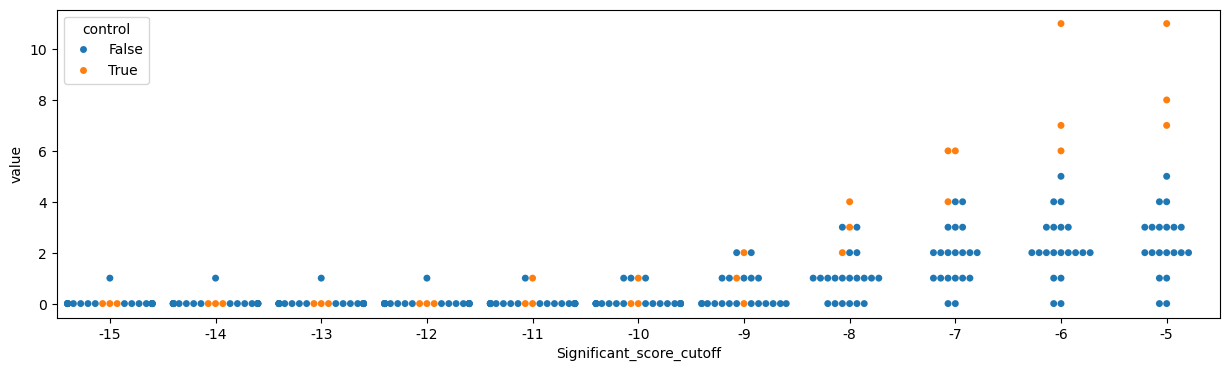

In [34]:
fig,ax=plt.subplots(figsize=(15,4))
sns.swarmplot(sig_filter_df_melt,x="variable",y="value",hue="control")
ax.set_xlabel("Significant_score_cutoff")
plt.savefig("./figure/pos_control_regulation.pdf")

In [35]:
express_df = global_df[global_df['gene_names'].isin(gene_seq[express_idx]) &
                       ((global_df['fc_by_rand_dist_cpm'] > (1+CUTOFF_FC)) | (global_df['fc_by_rand_dist_cpm'] < (1-CUTOFF_FC))) &
                       (global_df['Significance_score'] < -5) &
                       (global_df['pval-empirical'] < 0.001) &
                       (global_df['log(pval)-hypergeom'] < -3)].copy()

### Bar plot for ZNF91

In [36]:
plot_data = global_df[(global_df['gene_names'].isin(["SVA_C","SVA_D","SVA_F"])) &
          (global_df['TF_annotation']=="ZNF91")
         ][["gene_names","cpm_bg","cpm_perturb","Significance_score"]]
plot_data_melt = plot_data.loc[:,["gene_names","cpm_bg","cpm_perturb"]].melt(id_vars=["gene_names"])

In [37]:
plot_data

,gene_names,cpm_bg,cpm_perturb,Significance_score
9436822,SVA_C,21.221018,22.845429,-1.973165
9436823,SVA_D,90.729688,128.795413,-12.671608
9436825,SVA_F,33.793508,46.972107,-13.915989


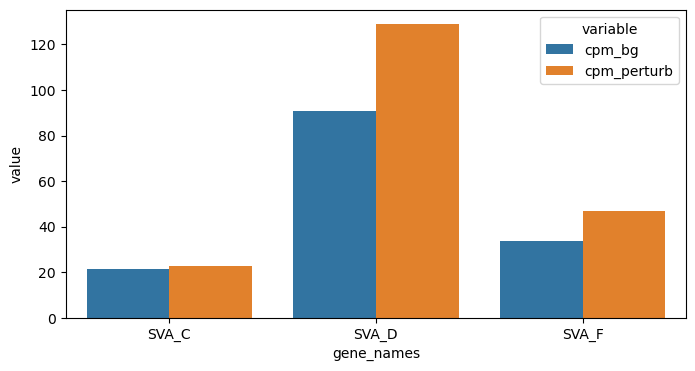

In [38]:
fig,ax=plt.subplots(figsize=(8,4))
sns.barplot(plot_data_melt,hue="variable",x="gene_names",y="value")
plt.savefig("./figure/ZNF91_perturb.pdf")

### Bar plot for TBX20

In [39]:
plot_data = global_df[(global_df['gene_names'].isin(["LTR30","HERV30-int"])) &
          (global_df['TF_annotation']=="TBX20")
         ][["gene_names","cpm_bg","cpm_perturb","Significance_score"]]
plot_data =  plot_data.iloc[[1,0],:]
plot_data_melt = plot_data.loc[:,["gene_names","cpm_bg","cpm_perturb"]].melt(id_vars=["gene_names"])

In [54]:
plot_data

,gene_names,cpm_bg,cpm_perturb,Significance_score
18022781,LTR30,1.901987,11.114018,-18.979673
18021492,HERV30-int,2.078471,18.265665,-22.614867


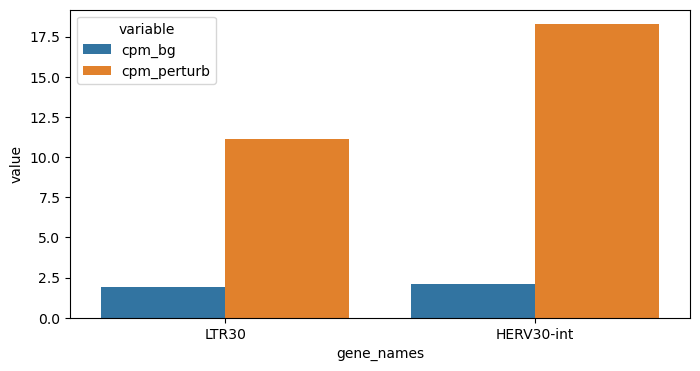

In [40]:
fig,ax=plt.subplots(figsize=(8,4))
sns.barplot(plot_data_melt,hue="variable",x="gene_names",y="value")
plt.savefig("./figure/TBX20_perturb.pdf")

### Process zinc finger table and prepare table for heatmap

In [41]:
zinc_fing_df = pd.read_csv('/project/GCRB/Hon_lab/s426305/Analysis/IGVF/20241209_WTC11_lenti_TFPerturb_RE/zinc_finger_gene_list.txt', sep='\t')

In [42]:
subset_express_df = express_df[(express_df['gene_names'].isin(RE_annotation_df['name'])) &
                               (express_df['TF_annotation'].isin(list(zinc_fing_df['Approved symbol'])))
                              ]
express_df_TE = express_df[(express_df['gene_names'].isin(RE_annotation_df['name']))
                       ]

In [43]:
subset_express_df.shape

(4177, 18)

In [44]:
subset_express_df_sub = subset_express_df.loc[:,["TF_annotation","gene_names",
                         "Significance_score","fc_by_rand_dist_cpm"]].copy()

# correct signs based on fold change
subset_express_df_sub["Significance_score_correct"] = subset_express_df_sub.apply(
    lambda x:x["Significance_score"] *(((x["fc_by_rand_dist_cpm"]<1)*2-1)),axis=1)

subset_express_df_sub = \
    subset_express_df_sub.loc[:,["TF_annotation","gene_names","Significance_score_correct"]]

In [45]:
express_df_sub = express_df_TE.loc[:,["TF_annotation","gene_names",
                         "Significance_score","fc_by_rand_dist_cpm"]].copy()

# correct signs based on fold change
express_df_sub["Significance_score_correct"] = express_df_sub.apply(
    lambda x:x["Significance_score"] *(((x["fc_by_rand_dist_cpm"]<1)*2-1)),axis=1)

express_df_sub = \
    express_df_sub.loc[:,["TF_annotation","gene_names","Significance_score_correct"]]

In [46]:
subset_express_df.shape

(4177, 18)

In [47]:
subset_express_df_pivot = subset_express_df_sub.pivot_table(index='gene_names',columns='TF_annotation',values='Significance_score_correct')
subset_express_df_pivot = subset_express_df_pivot.fillna(0)

express_df_pivot = express_df_sub.pivot_table(index='gene_names',columns='TF_annotation',values='Significance_score_correct')
express_df_pivot = express_df_pivot.fillna(0)

### How is the ChIP signal for identified TE derepression?

In [48]:
express_df_sub

,TF_annotation,gene_names,Significance_score_correct
6060,KLF2,LTR41B,-6.901607
17630,KLF2,LTR53,8.560136
27372,ZNF816,LTR28C,-5.972246
36152,ZNF816,CER,7.974175
38095,ZNF816,HERV3-int,9.104885
...,...,...,...
45639022,ZNF718,LTR85b,8.378953
45639275,ZNF718,MER53,9.277164
45639306,ZNF718,MER68C,5.241718
45639606,ZNF718,MLT1G3,6.276585


In [49]:
chip_signal_arr = []
for row in express_df_sub.itertuples():
    if (row.TF_annotation in te_zfp_df.index) and \
       (row.gene_names in te_zfp_df.columns):
        chip_signal = te_zfp_df.at[row.TF_annotation,row.gene_names]
    else:
        chip_signal = -1
    chip_signal_arr += [chip_signal]
    

In [50]:
express_df_sub["ChIP_signal"] = chip_signal_arr

In [51]:
express_df_sub[express_df_sub["ChIP_signal"]>-0.1].sort_values("Significance_score_correct").tail(30)

,TF_annotation,gene_names,Significance_score_correct,ChIP_signal
32422979,ZNF425,LTR19A,10.678354,0.000000
7806234,ZNF799,Harlequin-int,10.699246,0.000000
14733787,ZNF649,L1M2a,11.003904,0.000000
19736486,ZNF431,L1M3b,11.072184,0.000000
2607277,ZNF202,MER41-int,11.170948,0.000000
39208423,ZNF79,HERVL-int,11.253949,0.000000
19737447,ZNF431,MER68,11.258138,0.000000
28693322,ZNF782,SVA_C,11.344247,0.000000
35720685,ZNF562,LTR10C,11.524934,20.262562
31091215,ZNF480,L1PA15,11.537914,0.063851


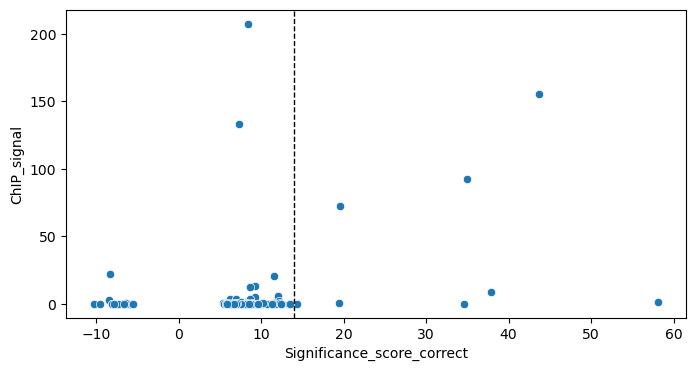

In [52]:
fig,ax=plt.subplots(figsize=(8,4))
sns.scatterplot(express_df_sub[express_df_sub["ChIP_signal"]>-0.1],
                x="Significance_score_correct",
                y="ChIP_signal"
               )
ax.axvline(14,c="black",linewidth=1,linestyle="--")
plt.savefig("./figure/ChIP_DE_comparison.pdf")